<a href="https://colab.research.google.com/github/kukanmani06/PRODIGY_ML_01/blob/main/ANN_Regression_Health_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
insurance_data = pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
insurance_data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(insurance_data['sex'])

LabelEncoder()

In [ ]:
insurance_data['sex'] = le.transform(insurance_data['sex'])

In [ ]:
le.fit(insurance_data['smoker'])
insurance_data['smoker'] = le.transform(insurance_data['smoker'])


In [ ]:
insurance_data['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
region_cat = pd.get_dummies(insurance_data['region'],prefix='region')
region_cat.head()

,region_northeast,region_northwest,region_southeast,region_southwest
0,False,False,False,True
1,False,False,True,False
2,False,False,True,False
3,False,True,False,False
4,False,True,False,False


In [ ]:
insurance_df = pd.concat([insurance_data,region_cat],axis=1)
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,southwest,16884.92400,False,False,False,True
1,18,1,33.770,1,0,southeast,1725.55230,False,False,True,False
2,28,1,33.000,3,0,southeast,4449.46200,False,False,True,False
3,33,1,22.705,0,0,northwest,21984.47061,False,True,False,False
4,32,1,28.880,0,0,northwest,3866.85520,False,True,False,False


<Axes: xlabel='charges'>

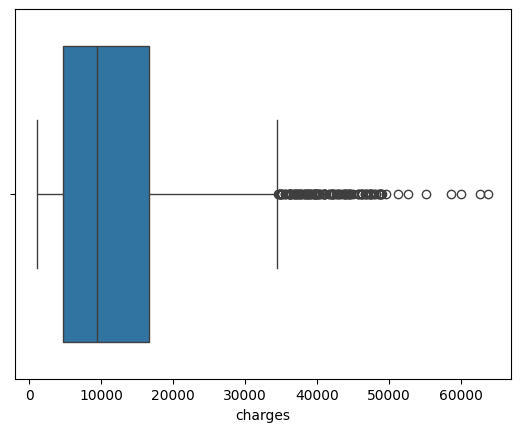

In [ ]:
sns.boxplot(insurance_df['charges'], orient = 'h')

In [ ]:
Q1 = insurance_df['charges'].quantile(0.25)
Q3 = insurance_df['charges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
insurance_df['charges'] = insurance_df['charges'].clip(lower = lower_bound, upper = upper_bound)

In [ ]:
insurance_df

,age,sex,bmi,children,smoker,region,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,southwest,16884.92400,False,False,False,True
1,18,1,33.770,1,0,southeast,1725.55230,False,False,True,False
2,28,1,33.000,3,0,southeast,4449.46200,False,False,True,False
3,33,1,22.705,0,0,northwest,21984.47061,False,True,False,False
4,32,1,28.880,0,0,northwest,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830,False,True,False,False
1334,18,0,31.920,0,0,northeast,2205.98080,True,False,False,False
1335,18,0,36.850,0,0,southeast,1629.83350,False,False,True,False
1336,21,0,25.800,0,0,southwest,2007.94500,False,False,False,True


In [ ]:
X = insurance_df.drop(['region', 'charges'], axis = 1)
Y = insurance_df['charges']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 1)

In [ ]:
x_train.shape

(1070, 9)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
# Role of optimizers are to minimize residual values (convergence) and adjust weights of each layer
from tensorflow.keras.optimizers import RMSprop

def build_model():
  model = Sequential()
  # Corrected: x_train.shape is a tuple, use [] for indexing, not () for calling.
  # x_train.shape[1] gives the number of features (columns).
  model.add(Input(shape = (x_train.shape[1],)))
  model.add(Dense(units=128, activation='relu'))
  model.add(Dense(units=256, activation='relu'))
  model.add(Dense(units=512, activation='relu'))
  model.add(Dense(units=1, activation='linear'))
  model.compile(optimizer=RMSprop(), loss='mse', metrics=['mae'])
  return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,401 (650.00 KB)

 Trainable params: 166,401 (650.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train,y_train,epochs=600,batch_size=32,validation_split=0.2)

Epoch 1/600
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 229923392.0000 - mae: 11364.3994 - val_loss: 165397232.0000 - val_mae: 8139.0059
Epoch 2/600
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 116192056.0000 - mae: 7345.1870 - val_loss: 94146656.0000 - val_mae: 7722.9946
Epoch 3/600
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 91175432.0000 - mae: 7889.6641 - val_loss: 93813856.0000 - val_mae: 8191.3145
Epoch 4/600
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 91607416.0000 - mae: 7975.3403 - val_loss: 93357256.0000 - val_mae: 7962.5142
Epoch 5/600
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 90681472.0000 - mae: 7942.3267 - val_loss: 93195448.0000 - val_mae: 7815.3521
Epoch 6/600
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 90523712.0000 - mae: 7829.6421 - val_loss: 95583760.0000 - val_mae: 8736.7607
Epoch 7/600
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 90481280.0000 - mae: 8041.1641 - val_loss: 92914120.0000 - val_mae: 7665.4932
Epoch 8/600
27/27 ━━━━━━━━━━━━━━━━━━

<Axes: >

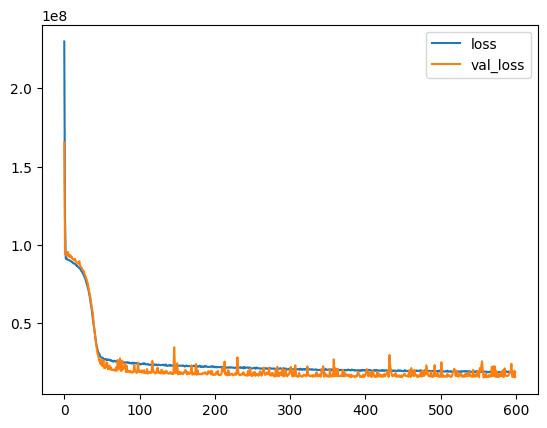

In [ ]:
pd.DataFrame(history.history)[['loss','val_loss']].plot()

In [ ]:
predictions=model.predict(x_test
                          )

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, predictions)

0.8160628418437809

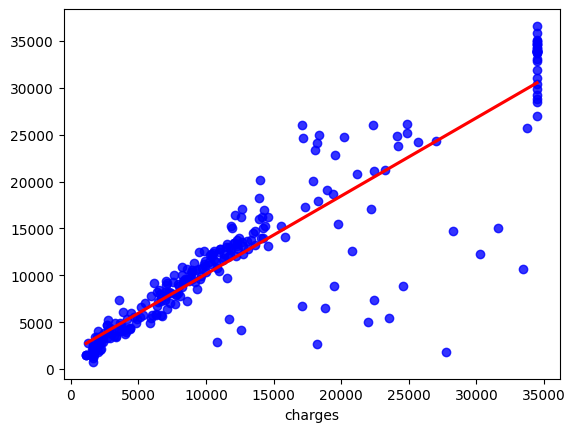

In [ ]:
import seaborn as sns
sns.regplot(x = y_test, y = predictions, ci = None, color = "b", line_kws={"color":"red"})
plt.show()

In [ ]:
results = pd.DataFrame(predictions, columns=['Prediction'])

In [ ]:
results['Actual Value'] = np.array(y_test)

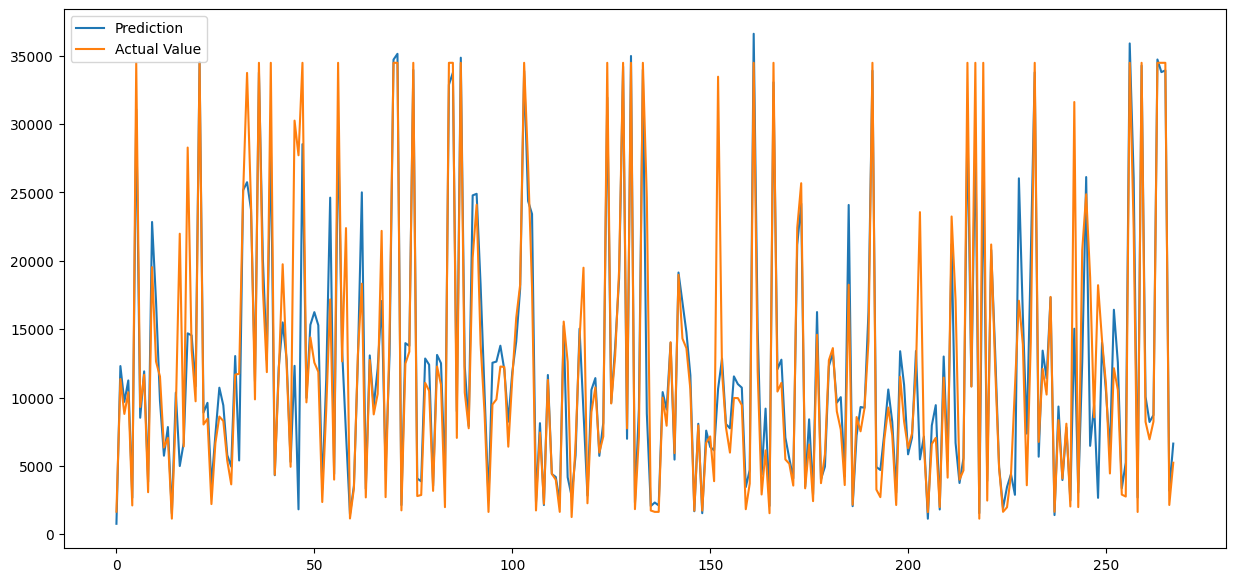

In [ ]:
results.plot(figsize = (15,7))
plt.show()